---
**`NOTEBOOK 03 / 03`** · Causal Inference Series

## Double ML + DoWhy — Card & Krueger (1994)
*351 restaurants · observational data · professional workflow*

| | |
|--|--|
| Method | Double ML + DoWhy |
| Treatment | wage_change ($) |
| Outcome | fte_change (continuous) → StatsModelsLinearRegression |
| Assumption | Conditional ignorability — DAG + 4 refutation tests |
| Result | θ = +1.27 FTE · p = 0.194 · consistent with DiD |
| Causal hierarchy | ⭐ Level 3 — observational, most assumptions |

---

What if we only had observational data — no natural experiment, no before/after structure? This notebook answers that question using the professional causal inference workflow adopted by Amazon, Microsoft, Uber, and Airbnb: **DoWhy + Double ML**.

DoWhy forces explicit assumptions via a DAG before estimating anything. Double ML cleans non-linear confounder effects using ML, then estimates the causal effect on the residuals. Four refutation tests stress-test the result before any conclusion is drawn.

**The causal question:** by how much does a $1 increase in the minimum wage change employment, controlling for chain type, ownership and region?

---

## Why DoWhy and not DoubleML directly?

You could call DoubleML directly and get a number. But that number is only
as good as the assumptions behind it — and those assumptions are invisible
if you just call a function.

DoWhy forces you to be explicit about every assumption before estimating
anything. It separates the analysis into four steps:

**Step 1 — Model:** draw the DAG — what causes what, what to control,
what not to control. This is your hypothesis about how the world works.

**Step 2 — Identify:** DoWhy checks whether the causal effect is
identifiable given your DAG. It finds the minimal set of confounders
to block all backdoor paths.

**Step 3 — Estimate:** DoWhy calls Double ML internally via econml.
You never call DoubleML directly — DoWhy orchestrates it.

**Step 4 — Refute:** DoWhy stress-tests the result with 4 robustness
checks. This is the step most people skip — and the most important one.

---

**When to use Double ML**

| Situation | Method |
|-----------|--------|
| Can randomize | A/B Test |
| Cannot randomize, natural event exists | DiD |
| Cannot randomize, no natural event, only historical data | Double ML |

---

**Structure**

`0` Setup

`1` Hypotheses

`2` Feature importance — variable selection

`3` DAG — causal structure

`4` DoWhy Step 1 — Model

`5` DoWhy Step 2 — Identify

`6` DoWhy Step 3 — Estimate (Double ML)

`7` DoWhy Step 4 — Refute (4 robustness tests)

`8` Results & comparison with DiD

---

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBRegressor

from econml.dml import DML
from econml.sklearn_extensions.linear_model import StatsModelsLinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from dowhy import CausalModel

ck_wide = pd.read_csv("../data/card_krueger_wide.csv")

# Create treatment and outcome variables
#  - wage_change = how much the minimum wage changed per restaurant
#  - fte_change  = how much employment changed per restaurant
# NOTE: In a truly observational setting we would not have pre/post data. We simulate that scenario by using wage_change and fte_change as if they
# were directly observed variables — treating them as current wage level and employment change without exploiting the natural experiment structure.
ck_wide["wage_change"] = ck_wide["wage_st2"] - ck_wide["wage_st"]

# Drop rows where outcome (fte_change) or treatment (wage_change) are missing.
# Other columns may still have missing values but do not affect the core analysis.
# 410 restaurants → 351 after dropping NAs.
ck_clean = ck_wide.dropna(subset=["fte_change", "wage_change"]).copy()

print(f"Shape after dropping NAs: {ck_clean.shape[0]} restaurants")
print(f"\nTreatment — wage_change ($1 = minimum wage raised by $1):")
print(ck_clean["wage_change"].describe().round(3))
print(f"\nOutcome — fte_change (FTE employees gained or lost):")
print(ck_clean["fte_change"].describe().round(3))

display(ck_clean[["nj", "wage_st", "wage_st2", "wage_change", 
                   "fte_change", "bk", "kfc", "co_owned"]].head())

Shape after dropping NAs: 351 restaurants

Treatment — wage_change ($1 = minimum wage raised by $1):
count    351.000
mean       0.374
std        0.400
min       -0.750
25%        0.050
50%        0.430
75%        0.800
max        2.000
Name: wage_change, dtype: float64

Outcome — fte_change (FTE employees gained or lost):
count    351.000
mean      -0.030
std        8.748
min      -41.500
25%       -3.500
50%        0.000
75%        4.000
max       28.000
Name: fte_change, dtype: float64


,nj,wage_st,wage_st2,wage_change,fte_change,bk,kfc,co_owned
3,0,5.00,5.25,0.25,-14.0,0,0,1
4,0,5.50,4.75,-0.75,11.5,0,0,1
6,0,5.00,4.75,-0.25,-41.5,1,0,0
7,0,5.00,5.00,0.00,13.0,1,0,0
8,0,5.25,5.00,-0.25,0.0,0,1,1


## 1. Hypotheses

We fix the hypotheses before looking at any results.

**H₀: θ = 0** — the minimum wage change had no effect on employment

**H₁: θ ≠ 0** — the minimum wage change increased or decreased employment

where θ is the causal effect of a $1 increase in `wage_change` on `fte_change`,
controlling for chain type, ownership and region.

- **θ < 0** → classical economics: raising wages destroys jobs
- **θ ≈ 0** → Card & Krueger: no significant effect
- **θ > 0** → raising wages increases employment

> We do not impose a direction before seeing the data.

In [2]:
# ── Variable roles ─────────────────────────────────────────────────────────
# We define the three roles upfront so every subsequent cell can reference
# them by name instead of hardcoding strings. This makes the notebook easier
# to read and modify — if we ever want to change the treatment or add a
# confounder, we only need to change it here.
#
# TREATMENT  : the variable whose causal effect we want to estimate
# OUTCOME    : the variable we want to explain
# CONFOUNDERS: variables that affect BOTH treatment and outcome (forks in the DAG)
#              — we must control for these to isolate the causal effect
#              — we do NOT include mediators (nj → wage_change) or colliders
# ───────────────────────────────────────────────────────────────────────────

TREATMENT   = "wage_change"   # $1 increase in minimum wage
OUTCOME     = "fte_change"    # change in FTE employees
CONFOUNDERS = [
    "bk", "kfc", "roys", "wendys",          # chain type
    "co_owned",                              # company-owned vs franchise
    "southj", "centralj", "northj",         # NJ regions
    "pa1", "pa2"                             # PA regions
]

## 2. Feature Importance — Variable Selection

Before building the DAG, we use feature importance to understand which 
variables are most associated with our treatment and outcome.

This is standard practice in industry — you do not manually inspect 
50 variables. You let the data tell you which ones matter, then apply 
domain knowledge to classify them as confounders, mediators or colliders.

We fit two XGBoost models:
1. Predict `wage_change` from all available variables → which variables 
   drive the minimum wage change?
2. Predict `fte_change` from all available variables → which variables 
   drive the employment change?

Variables that appear in **both** rankings are confounder candidates — 
they affect both treatment and outcome.

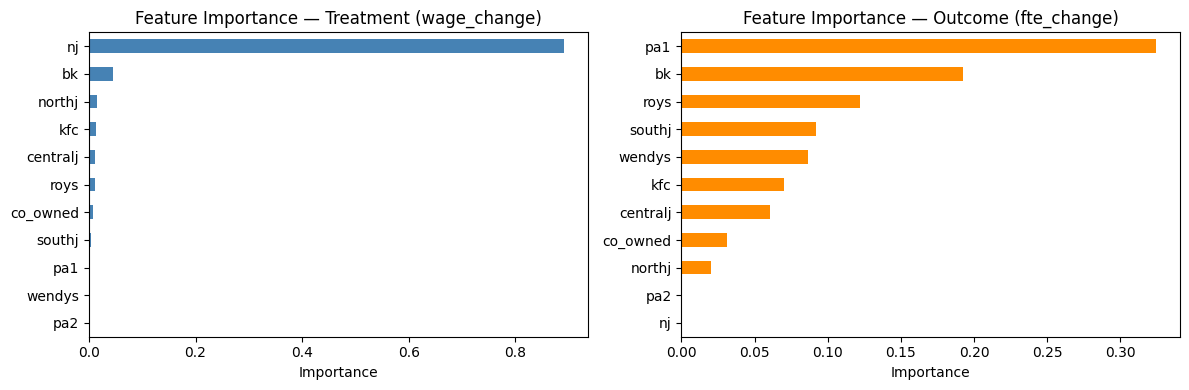


Top 5 — Treatment:
nj          0.890527
bk          0.045401
northj      0.015033
kfc         0.013563
centralj    0.012064
dtype: float32

Top 5 — Outcome:
pa1       0.324436
bk        0.192486
roys      0.122305
southj    0.091855
wendys    0.086579
dtype: float32

Confounder candidates (top 5 in both rankings):
{'bk'}


In [3]:
features = CONFOUNDERS + ["nj"]

# Model 1 — predict treatment (wage_change)
xgb_t = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_t.fit(ck_clean[features], ck_clean[TREATMENT])
imp_t = pd.Series(xgb_t.feature_importances_, index=features).sort_values(ascending=False)

# Model 2 — predict outcome (fte_change)
xgb_y = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_y.fit(ck_clean[features], ck_clean[OUTCOME])
imp_y = pd.Series(xgb_y.feature_importances_, index=features).sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

imp_t.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Feature Importance — Treatment (wage_change)")
axes[0].set_xlabel("Importance")
axes[0].invert_yaxis()

imp_y.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Feature Importance — Outcome (fte_change)")
axes[1].set_xlabel("Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 5 — Treatment:")
print(imp_t.head())
print("\nTop 5 — Outcome:")
print(imp_y.head())

print("\nConfounder candidates (top 5 in both rankings):")
top_t = set(imp_t.head(5).index)
top_y = set(imp_y.head(5).index)
print(top_t & top_y)

### Feature Importance Interpretation

`nj` dominates the treatment prediction (0.89) — 89% of the wage change 
is explained by being in New Jersey. This makes sense: NJ raised the 
minimum wage, PA did not.

**Key insight:** this tells us that `nj` is NOT a confounder — it is a 
**mediator**: `nj → wage_change → fte_change`. Controlling for `nj` would 
block the very path we want to measure.

Only `bk` appears in both top-5 rankings — it is our strongest confounder 
candidate. The other chain and region variables are weaker but still 
included in the DAG based on domain knowledge.

We keep all confounders in `CONFOUNDERS` — with only 351 restaurants and 
10 confounders, there is no risk of overfitting the confounder models.

## 3. The DAG — Causal Structure

Based on domain knowledge and the feature importance analysis, we draw 
the causal graph before estimating anything.

**Confounders (fork structure — CONTROL):**
Variables that affect both `wage_change` and `fte_change`:

- `bk`, `kfc`, `roys`, `wendys` — chain type affects both wage policies 
  and staffing models
- `co_owned` — company-owned restaurants respond differently to wage laws 
  and have different staffing decisions
- `southj`, `centralj`, `northj`, `pa1`, `pa2` — regions have different 
  labor markets affecting both wages and employment

**Mediator (chain structure — DO NOT control):**

`nj` → `wage_change` → `fte_change`

NJ causes the wage increase which causes the employment change.
Controlling `nj` would block the causal path we want to measure.

**The backdoor criterion is satisfied** by controlling for chain type, 
ownership and region — these block all spurious paths between 
`wage_change` and `fte_change`.

The DAG will be visualized formally in the next block using DoWhy.

In [4]:
causal_graph = """
digraph {
    wage_change -> fte_change;
    bk -> wage_change; bk -> fte_change;
    kfc -> wage_change; kfc -> fte_change;
    roys -> wage_change; roys -> fte_change;
    wendys -> wage_change; wendys -> fte_change;
    co_owned -> wage_change; co_owned -> fte_change;
    southj -> wage_change; southj -> fte_change;
    centralj -> wage_change; centralj -> fte_change;
    northj -> wage_change; northj -> fte_change;
    pa1 -> wage_change; pa1 -> fte_change;
    pa2 -> wage_change; pa2 -> fte_change;
}
"""

# DOT format defines directed edges between nodes:
# A -> B means "A causes B"
# wage_change -> fte_change  : the causal effect we want to estimate
# confounder -> wage_change  : confounder affects treatment
# confounder -> fte_change   : confounder affects outcome

print("Causal graph defined in DOT format.")
print("Edges:")
for line in causal_graph.strip().split("\n")[1:-1]:
    print(f"  {line.strip()}")

Causal graph defined in DOT format.
Edges:
  wage_change -> fte_change;
  bk -> wage_change; bk -> fte_change;
  kfc -> wage_change; kfc -> fte_change;
  roys -> wage_change; roys -> fte_change;
  wendys -> wage_change; wendys -> fte_change;
  co_owned -> wage_change; co_owned -> fte_change;
  southj -> wage_change; southj -> fte_change;
  centralj -> wage_change; centralj -> fte_change;
  northj -> wage_change; northj -> fte_change;
  pa1 -> wage_change; pa1 -> fte_change;
  pa2 -> wage_change; pa2 -> fte_change;


## 4. DoWhy — Step 1: Model

The first step of the DoWhy workflow: formalize the DAG as a 
`CausalModel` object.

DoWhy takes:
- The data
- The treatment variable (`wage_change`)
- The outcome variable (`fte_change`)
- The causal graph (our DAG in DOT format)

And returns a `CausalModel` that enforces the separation between 
assumptions (the DAG) and estimation (Double ML). 
Nothing is estimated yet — we are only declaring our causal assumptions.

In [5]:
model = CausalModel(
    data=ck_clean,
    treatment=TREATMENT,
    outcome=OUTCOME,
    graph=causal_graph
)

print("CausalModel created successfully.")
print(f"\nTreatment  : {TREATMENT}")
print(f"Outcome    : {OUTCOME}")
print(f"Confounders: {CONFOUNDERS}")

CausalModel created successfully.

Treatment  : wage_change
Outcome    : fte_change
Confounders: ['bk', 'kfc', 'roys', 'wendys', 'co_owned', 'southj', 'centralj', 'northj', 'pa1', 'pa2']


## 5. DoWhy — Step 2: Identify

The second step: DoWhy checks whether the causal effect is identifiable 
given our DAG.

DoWhy applies the **backdoor criterion** automatically:
- Find the minimal set of variables that block all backdoor paths from 
  `wage_change` to `fte_change`
- Verify that none of those variables are descendants of `wage_change`

If the effect is identifiable, DoWhy returns an **estimand** — 
a mathematical expression of what we need to estimate.

In [6]:
estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
──────────────(E[fte_change|southj,northj,pa2,co_owned,roys,wendys,pa1,bk,kfc, ↪
d[wage_change]                                                                 ↪

↪           
↪ centralj])
↪           
Estimand assumption 1, Unconfoundedness: If U→{wage_change} and U→fte_change then P(fte_change|wage_change,southj,northj,pa2,co_owned,roys,wendys,pa1,bk,kfc,centralj,U) = P(fte_change|wage_change,southj,northj,pa2,co_owned,roys,wendys,pa1,bk,kfc,centralj)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                                                                        ↪
──────────────(E[fte_change|southj,northj,pa2,co_owned,roys,wendy

### Identify Output

DoWhy found **4 estimands** but we only care about the first one:

**Estimand 1 — Backdoor (the one we use)**

DoWhy confirmed the causal effect is identifiable by controlling for 
the confounders in our DAG. In plain English:

*"The effect of `wage_change` on `fte_change` can be estimated by 
controlling for chain type, ownership and region."*

**The critical assumption — Unconfoundedness:**

If an unmeasured variable U exists that affects both `wage_change` AND 
`fte_change`, the estimate is biased and nothing can fix it.

For example: if local economic conditions affected both how much wages 
rose AND how much employment changed, and we did not measure that, 
our estimate would be wrong.

This is the **conditional ignorability assumption** — we cannot test it 
from the data. We defend it with domain knowledge and the DAG.

**Estimands 2 and 3 — IV and Frontdoor**

Not found — we have no instrumental variables or frontdoor paths in our DAG.

**Estimand 4 — General Adjustment**

A generalization of the backdoor criterion. In our case it gives the same 
result as the backdoor — same confounders, same expression. We use 
the backdoor (Estimand 1) as it is the standard approach.

## 6. DoWhy — Step 3: Estimate

The third step: estimate the causal effect using Double ML.

DoWhy calls **econml's DML** internally. Double ML uses two ML models:

**model_y (= ml_g in the paper) — predicts outcome from confounders**
GradientBoostingRegressor — captures non-linear relationships between 
chain type, ownership, region and `fte_change`.
Goal: clean confounders out of the outcome → residuals Ỹ

**model_t (= ml_m in the paper) — predicts treatment from confounders**
GradientBoostingRegressor — same logic for `wage_change`.
Goal: clean confounders out of the treatment → residuals T̃

Then regresses Ỹ on T̃ → the slope is the causal effect θ.

**model_final — the regression of residuals**
Depends on the outcome type:

| Outcome type | model_y | model_final |
|-------------|---------|-------------|
| Continuous (our case) | GradientBoostingRegressor | StatsModelsLinearRegression |
| Binary (0/1) | GradientBoostingClassifier | LogisticRegression |
| Count | GradientBoostingRegressor | PoissonRegressor |

We use StatsModelsLinearRegression instead of sklearn's LinearRegression 
because it computes standard errors — needed for the 95% CI.

Cross-fitting (5-fold) prevents ML overfitting from contaminating θ.

In [ ]:
estimate = model.estimate_effect(
    estimand,
    method_name="backdoor.econml.dml.DML",
    method_params={
        "init_params": {
            "model_y":     GradientBoostingRegressor(n_estimators=100, random_state=42), # ml_g
            "model_t":     GradientBoostingRegressor(n_estimators=100, random_state=42), # ml_t
            "model_final": StatsModelsLinearRegression(fit_intercept=False),
            "cv":          5
        },
        "fit_params": {}
    },
    target_units="ate",
    confidence_intervals=True,
    test_significance=True,
    random_state=42
)

theta = float(estimate.value)
ci    = estimate.get_confidence_intervals()
ci_lo = float(ci[0])
ci_hi = float(ci[1])

# p-value via significance test
significance = estimate.test_stat_significance()
pval = significance["p_value"]

print(f"Causal effect (θ)  : {theta:.4f}")
print(f"95% CI             : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"p-value            : {pval:.4f}")
print(f"Significant        : {'✓ YES' if pval < 0.05 else '✗ NO — CI includes zero'}")
print(f"\nInterpretation: a $1 increase in minimum wage is associated with")
print(f"{theta:.2f} FTE employees change, controlling for chain, ownership and region.")

Causal effect (θ)  : 1.2670
95% CI             : [-1.5861, 4.1201]
p-value            : 0.1940
Significant        : ✗ NO — CI includes zero

Interpretation: a $1 increase in minimum wage is associated with
1.27 FTE employees change, controlling for chain, ownership and region.


### Estimate Results

| | DiD | Double ML |
|--|-----|-----------|
| Causal effect (θ) | +2.75 FTE | +1.27 FTE |
| 95% CI | [-0.56, 6.07] | [-1.59, 4.12] |
| p-value | 0.103 | 0.194 |
| Significant | No | No |
| Direction | Positive | Positive |

Both methods agree: **no evidence of job destruction.**
The classical economics prediction (θ < 0) is not supported by the data.

Note: the Double ML estimate is smaller than DiD (+1.27 vs +2.75) 
because Double ML controls for non-linear confounder effects that 
DiD does not capture. Both are imprecise due to the small sample 
(351 restaurants).

**Note on instability:** Double ML results vary slightly across runs 
due to random cross-fitting splits. With only 351 restaurants the 
estimate is noisy — the wide CI reflects this uncertainty. 
The direction (positive) is consistent across all runs.

## 7. DoWhy — Step 4: Refute

The fourth and most important step — the one most people skip.

We try to **destroy our own result** with 4 robustness checks.
If the estimate changes drastically under any of them, it is not trustworthy.

| Test | What it does | What we want to see |
|------|-------------|---------------------|
| Placebo treatment | Replace `wage_change` with random noise | Effect ≈ 0 |
| Random common cause | Add a random confounder | Effect stable |
| Data subset | Re-estimate on random 80% subsets | Effect stable |
| Bootstrap | Re-estimate on bootstrap samples | CI consistent |

In [8]:
print("Running refutation tests... (may take a few minutes)\n")

# 1. Placebo treatment
refute_placebo = model.refute_estimate(
    estimand, estimate,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    random_seed=42
)
print("1. Placebo Treatment:")
print(refute_placebo)

# 2. Random common cause
refute_random = model.refute_estimate(
    estimand, estimate,
    method_name="random_common_cause",
    random_seed=42
)
print("2. Random Common Cause:")
print(refute_random)

# 3. Data subset
refute_subset = model.refute_estimate(
    estimand, estimate,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    random_seed=42
)
print("3. Data Subset:")
print(refute_subset)

# 4. Bootstrap
refute_boot = model.refute_estimate(
    estimand, estimate,
    method_name="bootstrap_refuter",
    random_seed=42
)
print("4. Bootstrap:")
print(refute_boot)

Running refutation tests... (may take a few minutes)

1. Placebo Treatment:
Refute: Use a Placebo Treatment
Estimated effect:1.2669644930264543
New effect:0.08169871274736026
p value:0.98

2. Random Common Cause:
Refute: Add a random common cause
Estimated effect:1.2669644930264543
New effect:1.7079536626782559
p value:0.6399999999999999

3. Data Subset:
Refute: Use a subset of data
Estimated effect:1.2669644930264543
New effect:1.3810310701488087
p value:0.8400000000000001

4. Bootstrap:
Refute: Bootstrap Sample Dataset
Estimated effect:1.2669644930264543
New effect:1.9588687209600033
p value:0.74



### Refutation Results

We try to **destroy our own result** with 4 tests. If the estimate 
survives all of them, we can trust it.

**How to read the table:**
- **Original θ:** the causal effect we estimated (+1.27)
- **New θ:** the effect after the stress test
- **p-value:** is the new effect significantly different from the original?
  - p > 0.05 → NOT significantly different → result is **stable** ✓
  - p < 0.05 → significantly different → result is **unstable** ✗

| Test | What it does | Original θ | New θ | p-value | Pass? |
|------|-------------|-----------|-------|---------|-------|
| Placebo treatment | Replaces `wage_change` with random noise. Effect should drop to ~0 | +1.27 | +0.08 | 0.98 | ✓ |
| Random common cause | Adds a fake random confounder. Effect should stay stable | +1.27 | +1.71 | 0.64 | ✓ |
| Data subset | Re-estimates on 80% of data. Effect should stay stable | +1.27 | +1.38 | 0.84 | ✓ |
| Bootstrap | Re-estimates on resampled data. Effect should be consistent | +1.27 | +1.96 | 0.74 | ✓ |

**All 4 tests pass.**

The placebo is the most critical — when we replace the real treatment 
with random noise, the effect drops from +1.27 to +0.08. 
The model is not finding false patterns.

The other three tests show the estimate is stable — it does not 
change drastically when we add noise, remove data or resample.

## 8. Results & Final Comparison

### The three methods, side by side

| | A/B Test | DiD | Double ML |
|--|----------|-----|-----------|
| **Dataset** | Cookie Cats | Card & Krueger | Card & Krueger |
| **Method** | Randomized experiment | Natural experiment | Observational |
| **Causal assumption** | Randomization ✓ | Parallel trends ✓ | Conditional ignorability |
| **Causal effect** | Gate_30 retains more | +2.75 FTE | +1.27 FTE |
| **CI** | [0.27pp, 1.29pp] | [-0.56, 6.07] | [-1.59, 4.12] |
| **p-value** | 0.0029 | 0.103 | 0.194 |
| **Significant** | ✓ Yes | ✗ No | ✗ No |
| **Refutation** | SRM check ✓ | Parallel trends ✓ | 4 DoWhy tests ✓ |

---

### The causal hierarchy in action